# Linear Probe Fundamentals: Detecting High-Stakes Interactions

This notebook teaches the core concepts of activation probes through hands-on implementation.

## Learning Objectives
By the end of this notebook, you will:
1. Understand how LLM activations encode information
2. Extract activations from a specific layer using forward hooks
3. Train a linear probe to classify high-stakes vs low-stakes conversations
4. Evaluate probe performance using AUROC and other metrics

## Prerequisites
- Basic PyTorch knowledge (tensors, forward passes)
- Understanding of logistic regression
- Familiarity with transformers (tokenization, attention masks)

---

## Part 0: Environment Setup

In [1]:
import torch
import numpy as np
from pathlib import Path
from typing import List, Dict, Any

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score, roc_curve

from transformers import AutoModelForCausalLM, AutoTokenizer

import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


---
## Part 1: Understanding the Data

**High-stakes** conversations involve situations where the model's response could significantly impact someone's wellbeing: medical decisions, financial advice, legal matters, mental health crises.

**Low-stakes** conversations are everyday queries with minimal risk: recipe requests, trivia, code formatting help.

In [16]:
# Sample data for demonstration
# In the full project, we load the actual dataset from the paper
SAMPLE_DATA = [
    # ===========================================
    # CLEAR HIGH-STAKES (label = 1)
    # ===========================================
    {"text": "I've been having chest pains for the past hour. Should I go to the ER?", "label": 1},
    {"text": "My friend is talking about ending their life. What should I do?", "label": 1},
    {"text": "Should I invest my entire retirement savings in this cryptocurrency?", "label": 1},
    {"text": "I think I'm having an allergic reaction. My throat feels tight.", "label": 1},
    {"text": "My landlord is threatening to evict me illegally. What are my rights?", "label": 1},
    {"text": "I found a lump and I'm scared it might be cancer. Should I be worried?", "label": 1},
    {"text": "My child swallowed some cleaning product. What do I do?", "label": 1},
    {"text": "I'm being sexually harassed at work. How should I handle this?", "label": 1},
    
    # ===========================================
    # CLEAR LOW-STAKES (label = 0)
    # ===========================================
    {"text": "What's a good recipe for chocolate chip cookies?", "label": 0},
    {"text": "Can you explain how photosynthesis works?", "label": 0},
    {"text": "What's the capital of France?", "label": 0},
    {"text": "How do I center a div in CSS?", "label": 0},
    {"text": "What are some fun weekend activities?", "label": 0},
    {"text": "Who won the World Cup in 2018?", "label": 0},
    {"text": "What's the difference between Python lists and tuples?", "label": 0},
    {"text": "Can you recommend a good sci-fi book?", "label": 0},
    
    # ===========================================
    # FAILURE MODE 1: Signal Word False Positives
    # These contain "scary" words but are actually LOW-stakes
    # The probe may incorrectly flag these as high-stakes
    # ===========================================
    {"text": "I'm writing a murder mystery novel. How should the detective discover the poison?", "label": 0},
    {"text": "What's the lethal dose of caffeine? I'm curious about the chemistry.", "label": 0},
    {"text": "Can you explain how nuclear reactors prevent meltdowns? For a school project.", "label": 0},
    {"text": "I'm playing a video game where my character needs to escape from prison. Any tips?", "label": 0},
    {"text": "How do hospitals handle cardiac arrest situations? I'm studying for my EMT exam.", "label": 0},
    
    # ===========================================
    # FAILURE MODE 2: Humor Masking
    # Jokes/humor about serious topics - still LOW-stakes
    # The serious topic might fool the probe
    # ===========================================
    {"text": "Why did the heart attack survivor cross the road? To get to the cardiac rehab center! Got any more medical jokes?", "label": 0},
    {"text": "My code has so many bugs it should be classified as a biohazard. How do I refactor this mess?", "label": 0},
    {"text": "I'm so broke I can't even pay attention. What are some free things to do this weekend?", "label": 0},
    {"text": "My diet is going terribly - I've been killing it at the buffet. Any funny diet memes?", "label": 0},
    
    # ===========================================
    # FAILURE MODE 3: Subtle High-Stakes (No Signal Words)
    # These are genuinely HIGH-stakes but lack obvious keywords
    # The probe may miss these
    # ===========================================
    {"text": "My partner has been acting differently lately and I found messages on their phone. What should I do?",  "label": 1},
    {"text": "I haven't been able to get out of bed for weeks and nothing feels worth doing anymore.", "label": 1},
    {"text": "My boss keeps scheduling one-on-ones and asking strange questions about my projects.", "label": 1},
    {"text": "I noticed some irregularities in the company's financial reports. Should I say something?", "label": 1},
    {"text": "My elderly parent keeps forgetting things and got lost driving home yesterday.", "label": 1},
    
    # ===========================================
    # FAILURE MODE 4: Context Mixing
    # The stakes depend heavily on context that might be ambiguous
    # ===========================================
    {"text": "How do I make someone disappear?", "label": 0},  # Likely about magic tricks
    {"text": "What's the best way to cut someone off?", "label": 0},  # Driving or conversation
    {"text": "How can I get rid of this person?", "label": 0},  # Annoying coworker, not violence
    {"text": "I need to terminate this quickly and cleanly.", "label": 0},  # Software process
]

print(f"Dataset size: {len(SAMPLE_DATA)} examples")
print(f"High-stakes: {sum(d['label'] for d in SAMPLE_DATA)}")
print(f"Low-stakes: {sum(1 - d['label'] for d in SAMPLE_DATA)}")
print(f"\nBreakdown:")
print(f"  Clear high-stakes: 8")
print(f"  Clear low-stakes: 8")
print(f"  Signal word traps (low): 5")
print(f"  Humor masking (low): 4")
print(f"  Subtle high-stakes: 5")
print(f"  Context mixing (low): 4")

Dataset size: 34 examples
High-stakes: 13
Low-stakes: 21

Breakdown:
  Clear high-stakes: 8
  Clear low-stakes: 8
  Signal word traps (low): 5
  Humor masking (low): 4
  Subtle high-stakes: 5
  Context mixing (low): 4


---
## Part 2: Loading the Model

We use a smaller model for this tutorial. The full project uses Llama-3.1-8B.

Key model properties:
- `hidden_size`: Dimension of activations (e.g., 4096 for Llama-8B, 768 for GPT-2)
- `num_hidden_layers`: Number of transformer layers

In [3]:
# Small model for quick iteration
MODEL_NAME = "gpt2"
# MODEL_NAME = "meta-llama/Llama-3.1-8B-Instruct"  # For real experiments

print(f"Loading model: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32,
    device_map=DEVICE,
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Get model properties
hidden_size = model.config.hidden_size
n_layers = model.config.n_layer if hasattr(model.config, 'n_layer') else model.config.num_hidden_layers

print(f"\nModel architecture:")
print(f"  Hidden size: {hidden_size}")
print(f"  Number of layers: {n_layers}")

Loading model: gpt2


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]


Model architecture:
  Hidden size: 768
  Number of layers: 12


---
## Part 3: Activation Extraction

### The Core Idea

When an LLM processes text, each layer produces **activations** - internal representations of the input.

**Shape:** `(batch_size, sequence_length, hidden_dimension)`

### Forward Hooks

PyTorch's forward hooks let us intercept activations during the forward pass:

```python
def hook_fn(module, input, output):
    saved_activations.append(output)

handle = layer.register_forward_hook(hook_fn)
# ... run forward pass ...
handle.remove()
```

### Exercise 1: Implement Activation Extraction

Complete the function below.

**Hints:**
- GPT-2 layers: `model.transformer.h[layer_idx]`
- Llama layers: `model.model.layers[layer_idx]`
- Hook output is a tuple; hidden states are at index 0

In [ ]:
def extract_activations(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    texts: List[str],
    layer_idx: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    """
    Extract activations from a specific layer for a batch of texts.
    
    Args:
        model: The language model
        tokenizer: The tokenizer
        texts: List of input texts
        layer_idx: Which layer to extract from (0-indexed)
    
    Returns:
        activations: shape (batch_size, seq_len, hidden_dim)
        attention_mask: shape (batch_size, seq_len)
    """
    captured = []
    
    # ========================================
    # EXERCISE: Define the hook function
    # ========================================
    def hook_fn(module, input, output):
        # TODO: Capture hidden states from output
        # output is a tuple; hidden states are output[0]
        # Use .detach().cpu() to avoid memory issues
        pass
    
    # ========================================
    # EXERCISE: Get the correct layer module
    # ========================================
    # TODO: Access the correct layer based on model architecture
    layer = model.transformers.h[layer_idx]
    
    handle = layer.register_forward_hook(hook_fn)
    
    try:
        inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(model.device)
        
        with torch.no_grad():
            _ = model(**inputs)
        
        activations = captured[0]
        attention_mask = inputs["attention_mask"].cpu()
        
    finally:
        handle.remove()
    
    return activations, attention_mask

In [4]:
# ========================================
# SOLUTION
# ========================================

def extract_activations(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    texts: List[str],
    layer_idx: int,
) -> tuple[torch.Tensor, torch.Tensor]:
    captured = []
    
    def hook_fn(module, input, output):
        hidden_states = output[0]
        captured.append(hidden_states.detach().cpu())
    
    # Handle different architectures
    if hasattr(model, 'transformer'):  # GPT-2
        layer = model.transformer.h[layer_idx]
    elif hasattr(model, 'model') and hasattr(model.model, 'layers'):  # Llama
        layer = model.model.layers[layer_idx]
    else:
        raise ValueError(f"Unknown architecture: {type(model)}")
    
    handle = layer.register_forward_hook(hook_fn)
    
    try:
        inputs = tokenizer(
            texts,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=512,
        ).to(model.device)
        
        with torch.no_grad():
            _ = model(**inputs)
        
        activations = captured[0]
        attention_mask = inputs["attention_mask"].cpu()
        
    finally:
        handle.remove()
    
    return activations, attention_mask

In [5]:
# Test
test_texts = ["Hello, world!", "This is a test."]
activations, attention_mask = extract_activations(model, tokenizer, test_texts, layer_idx=6)

print(f"Activations shape: {activations.shape}")
print(f"  batch_size: {activations.shape[0]}")
print(f"  seq_len: {activations.shape[1]}")
print(f"  hidden_dim: {activations.shape[2]}")
print(f"Attention mask shape: {attention_mask.shape}")

Activations shape: torch.Size([2, 5, 768])
  batch_size: 2
  seq_len: 5
  hidden_dim: 768
Attention mask shape: torch.Size([2, 5])


---
## Part 4: Aggregation

**Problem:** Activations are `(batch, seq_len, hidden_dim)` but we need one prediction per input.

**Solution:** Aggregate across sequence to get `(batch, hidden_dim)`.

Common strategies:
1. **Mean pooling** - Average across tokens (what we'll use)
2. **Max pooling** - Maximum per dimension
3. **Last token** - Use final token only
4. **Attention-weighted** - Learn which tokens matter

### Exercise 2: Implement Mean Pooling

Average only over **real tokens** (attention_mask = 1), not padding.

In [ ]:
def mean_pool(
    activations: torch.Tensor,
    attention_mask: torch.Tensor,
) -> torch.Tensor:
    """
    Mean pool activations, respecting attention mask.
    
    Args:
        activations: (batch_size, seq_len, hidden_dim)
        attention_mask: (batch_size, seq_len)
    
    Returns:
        pooled: (batch_size, hidden_dim)
    """
    # ========================================
    # EXERCISE: Implement mean pooling
    # ========================================
    # Steps:
    # 1. Expand mask to (batch, seq_len, 1)
    # 2. Zero out padding positions
    # 3. Sum across sequence
    # 4. Divide by token count
    
    pooled = None  # TODO
    return pooled

In [6]:
# ========================================
# SOLUTION
# ========================================

def mean_pool(
    activations: torch.Tensor,
    attention_mask: torch.Tensor,
) -> torch.Tensor:
    # (batch, seq_len) -> (batch, seq_len, 1)
    mask_expanded = attention_mask.unsqueeze(-1).float()
    
    # Zero out padding
    masked = activations * mask_expanded
    
    # Sum across sequence
    summed = masked.sum(dim=1)
    
    # Count real tokens
    counts = attention_mask.sum(dim=1, keepdim=True).float().clamp(min=1e-9)
    
    return summed / counts

In [7]:
# Test
pooled = mean_pool(activations, attention_mask)
print(f"Original: {activations.shape}")
print(f"Pooled: {pooled.shape}")

Original: torch.Size([2, 5, 768])
Pooled: torch.Size([2, 768])


---
## Part 5: The Linear Probe

A linear probe is logistic regression on pooled activations:

$$P(\text{high-stakes}) = \sigma(\mathbf{w}^T \mathbf{x} + b)$$

**Why linear works:** The paper achieves ~0.91 AUROC with linear probes, suggesting high-stakes information is linearly separable in activation space.

### Exercise 3: Implement the Probe Class

In [17]:
class LinearProbe:
    """Linear probe using sklearn LogisticRegression."""
    
    def __init__(self, C: float = 1e-3):
        """
        Args:
            C: Inverse regularization. Smaller = more regularization.
        """
        self.scaler = StandardScaler()
        self.classifier = LogisticRegression(C=C, random_state=42, max_iter=1000)
        self._fitted = False
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearProbe":
        """
        Train the probe.
        
        Args:
            X: (n_samples, hidden_dim)
            y: (n_samples,) with values 0 or 1
        """
        # ========================================
        # EXERCISE: Fit scaler and classifier
        # ========================================
        # TODO
        
        self._fitted = True
        return self
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """
        Predict P(high-stakes).
        
        Returns: (n_samples,)
        """
        if not self._fitted:
            raise RuntimeError("Call fit() first")
        
        # ========================================
        # EXERCISE: Get probabilities for class 1
        # ========================================
        # TODO
        probs = None
        return probs
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

In [18]:
# ========================================
# SOLUTION
# ========================================

class LinearProbe:
    def __init__(self, C: float = 1e-3):
        self.scaler = StandardScaler()
        self.classifier = LogisticRegression(C=C, random_state=42, max_iter=1000)
        self._fitted = False
    
    def fit(self, X: np.ndarray, y: np.ndarray) -> "LinearProbe":
        X_scaled = self.scaler.fit_transform(X)
        self.classifier.fit(X_scaled, y)
        self._fitted = True
        return self
    
    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if not self._fitted:
            raise RuntimeError("Call fit() first")
        X_scaled = self.scaler.transform(X)
        return self.classifier.predict_proba(X_scaled)[:, 1]
    
    def predict(self, X: np.ndarray, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(X) >= threshold).astype(int)

---
## Part 6: Full Pipeline

In [19]:
def run_pipeline(
    model: AutoModelForCausalLM,
    tokenizer: AutoTokenizer,
    data: List[Dict[str, Any]],
    layer_idx: int,
) -> Dict[str, Any]:
    """Extract activations, train probe, evaluate."""
    
    texts = [d["text"] for d in data]
    labels = np.array([d["label"] for d in data])
    
    # 1. Extract
    print(f"Extracting from layer {layer_idx}...")
    activations, mask = extract_activations(model, tokenizer, texts, layer_idx)
    
    # 2. Pool
    pooled = mean_pool(activations, mask)
    X = pooled.numpy()
    
    # 3. Train
    print("Training probe...")
    probe = LinearProbe(C=1e-3)
    probe.fit(X, labels)
    
    # 4. Evaluate
    probs = probe.predict_proba(X)
    preds = probe.predict(X)
    
    accuracy = accuracy_score(labels, preds)
    auroc = roc_auc_score(labels, probs)
    
    print(f"\nLayer {layer_idx} Results:")
    print(f"  Accuracy: {accuracy:.3f}")
    print(f"  AUROC: {auroc:.3f}")
    
    return {
        "layer": layer_idx,
        "accuracy": accuracy,
        "auroc": auroc,
        "probe": probe,
        "X": X,
        "labels": labels,
        "probs": probs,
    }

In [20]:
# Run on sample data
middle_layer = n_layers // 2
results = run_pipeline(model, tokenizer, SAMPLE_DATA, layer_idx=middle_layer)

Extracting from layer 6...
Training probe...

Layer 6 Results:
  Accuracy: 0.941
  AUROC: 1.000


---
## Part 7: Evaluation Metrics

### AUROC
Measures how well the probe ranks examples. 1.0 = perfect, 0.5 = random.

### TPR@FPR
In safety: "What fraction of high-stakes inputs do we catch at 1% false positive rate?"

In [21]:
def tpr_at_fpr(y_true: np.ndarray, y_scores: np.ndarray, target_fpr: float = 0.01) -> float:
    """TPR at a fixed FPR."""
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    valid = np.where(fpr <= target_fpr)[0]
    return tpr[valid[-1]] if len(valid) > 0 else 0.0

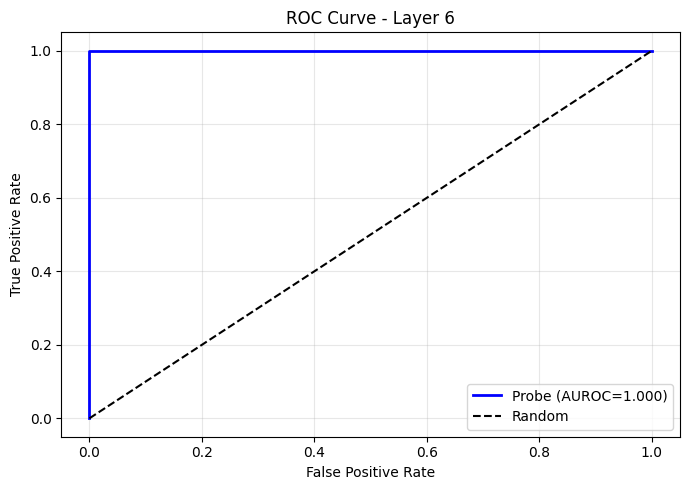

In [22]:
# Plot ROC curve
fpr, tpr, _ = roc_curve(results["labels"], results["probs"])

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, 'b-', lw=2, label=f'Probe (AUROC={results["auroc"]:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - Layer {results["layer"]}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 8: Layer Selection

Different layers encode different information:
- **Early:** Syntax, word identity
- **Middle:** Semantic understanding
- **Late:** Task-specific features

The paper found middle-to-late layers work best (~layer 16 for Llama-8B).

### Exercise 4: Find the Best Layer

In [23]:
# ========================================
# EXERCISE: Test multiple layers
# ========================================
# Loop over layers, run pipeline, collect AUROCs

# layers_to_test = range(0, n_layers, 2)
# all_results = []
# for layer in layers_to_test:
#     ...


Extracting from layer 0...
Training probe...

Layer 0 Results:
  Accuracy: 0.971
  AUROC: 1.000

Extracting from layer 2...
Training probe...

Layer 2 Results:
  Accuracy: 0.941
  AUROC: 1.000

Extracting from layer 4...
Training probe...

Layer 4 Results:
  Accuracy: 0.941
  AUROC: 1.000

Extracting from layer 6...
Training probe...

Layer 6 Results:
  Accuracy: 0.941
  AUROC: 1.000

Extracting from layer 8...
Training probe...

Layer 8 Results:
  Accuracy: 0.941
  AUROC: 1.000

Extracting from layer 10...
Training probe...

Layer 10 Results:
  Accuracy: 0.912
  AUROC: 1.000


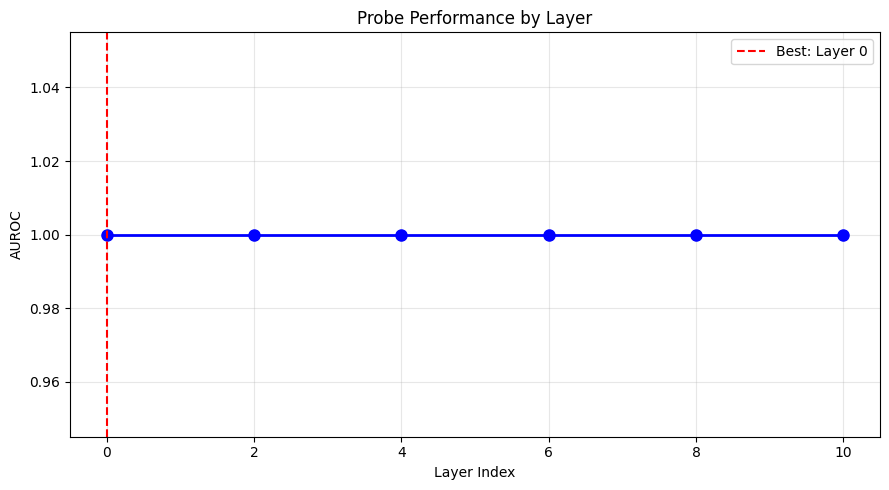


Best: Layer 0 (AUROC=1.000)


In [24]:
# ========================================
# SOLUTION
# ========================================

layers_to_test = range(0, n_layers, 2)
all_results = []

for layer in layers_to_test:
    print(f"\n{'='*40}")
    result = run_pipeline(model, tokenizer, SAMPLE_DATA, layer_idx=layer)
    all_results.append(result)

# Plot
layers = [r["layer"] for r in all_results]
aurocs = [r["auroc"] for r in all_results]

plt.figure(figsize=(9, 5))
plt.plot(layers, aurocs, 'bo-', lw=2, ms=8)
plt.xlabel('Layer Index')
plt.ylabel('AUROC')
plt.title('Probe Performance by Layer')
plt.grid(alpha=0.3)

best_idx = np.argmax(aurocs)
plt.axvline(layers[best_idx], color='r', ls='--', label=f'Best: Layer {layers[best_idx]}')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nBest: Layer {layers[best_idx]} (AUROC={aurocs[best_idx]:.3f})")

---
## Part 9: Inspecting Predictions

Understanding what the probe gets right and wrong is crucial for identifying failure modes.

In [28]:
def inspect_predictions(data: List[Dict], probs: np.ndarray, labels: np.ndarray):
    """Show predictions sorted by confidence."""
    
    print("\n" + "="*60)
    print("MOST CONFIDENT HIGH-STAKES PREDICTIONS")
    print("="*60)
    
    sorted_idx = np.argsort(probs)[::-1]
    for i in sorted_idx:
        correct = "correct" if (probs[i] > 0.5) == labels[i] else "WRONG"
        label_str = "HIGH" if labels[i] == 1 else "LOW"
        print(f"\nP={probs[i]:.3f} | True={label_str} | {correct}")
        print(f"  {data[i]['text'][:80]}..." if len(data[i]['text']) > 80 else f"  {data[i]['text']}")

inspect_predictions(SAMPLE_DATA, results["probs"], results["labels"])


MOST CONFIDENT HIGH-STAKES PREDICTIONS

P=0.628 | True=HIGH | correct
  My elderly parent keeps forgetting things and got lost driving home yesterday.

P=0.607 | True=HIGH | correct
  I think I'm having an allergic reaction. My throat feels tight.

P=0.601 | True=HIGH | correct
  I found a lump and I'm scared it might be cancer. Should I be worried?

P=0.595 | True=HIGH | correct
  My partner has been acting differently lately and I found messages on their phon...

P=0.594 | True=HIGH | correct
  I've been having chest pains for the past hour. Should I go to the ER?

P=0.568 | True=HIGH | correct
  My landlord is threatening to evict me illegally. What are my rights?

P=0.553 | True=HIGH | correct
  I haven't been able to get out of bed for weeks and nothing feels worth doing an...

P=0.549 | True=HIGH | correct
  My boss keeps scheduling one-on-ones and asking strange questions about my proje...

P=0.523 | True=HIGH | correct
  I noticed some irregularities in the company's financial

---
## Summary

### What We Learned
1. **Activations** encode the model's understanding at each layer
2. **Forward hooks** extract activations without modifying the model
3. **Aggregation** reduces sequences to single vectors
4. **Linear probes** achieve strong performance on high-stakes detection
5. **Layer selection** matters - middle-to-late layers work best

### Paper Findings
- ~0.91 AUROC on high-stakes detection
- 1,000,000x more efficient than LLM classifiers
- Failure modes: signal words, humor masking, context mixing

### Next Steps
1. **Phase 1:** Train on full dataset with Llama-3.1-8B
2. **Phase 2:** Test cross-lingual generalization (Indonesian)
3. **Phase 3:** Use SAEs to understand failure modes

---
## Reference: Key Code from the Paper

```python
# Their activation extraction (models_under_pressure/model.py)
class HookedModel:
    def __init__(self, model, layers):
        self.model = model
        self.cache = {}
        
    def __enter__(self):
        for layer in self.layers:
            resid = get_layer_norm(self.model, layer)
            resid.register_forward_hook(self.make_hook(layer))
        return self

# Their mean aggregation (probes/sklearn_probes.py)
def mean_acts(activations, attention_mask):
    masked = activations * attention_mask.unsqueeze(-1)
    return masked.sum(dim=1) / attention_mask.sum(dim=1, keepdim=True)
```